# Seaborn

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\Jessan\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [21]:
# Elección de un tema para seaborn
sns.set_theme(style="whitegrid", context="notebook")

In [4]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)


| Columna | Descripción |
|---|---|
| survived | Indica si sobrevivió: 0 = no, 1 = sí |
| pclass | Clase del boleto: 1, 2 o 3 |
| sex | Sexo del pasajero |
| age | Edad del pasajero |
| sibsp | Número de hermanos o cónyuges a bordo |
| parch | Número de padres o hijos a bordo |
| fare | Tarifa pagada |
| embarked | Puerto de embarque |
| class | Clase como variable categórica |
| who | Hombre, mujer o niño |
| adult_male | Indica si era hombre adulto |
| deck | Cubierta del barco |
| embark_town | Ciudad de embarque |
| alive | Indica si sobrevivió como texto |
| alone | Indica si viajaba solo |

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [7]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [8]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
missing_percentage = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      * 100
)

missing_percentage

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(107)

In [11]:
df[df.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
## En caso de que se deseen borrar duplicados
##df.drop_duplicates() --> un df 
##df.drop_duplicates(inplace=True) -- Modificar el dataframe original

In [12]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df.describe(include=["object", "category", "bool"])

C:\Users\Jessan\AppData\Local\Temp\ipykernel_1860\1459574463.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object", "category", "bool"])


,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


In [14]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [15]:
df["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [16]:
df["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [17]:
df["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [18]:
df["alone"].value_counts()

alone
True     537
False    354
Name: count, dtype: int64

# Seaborn

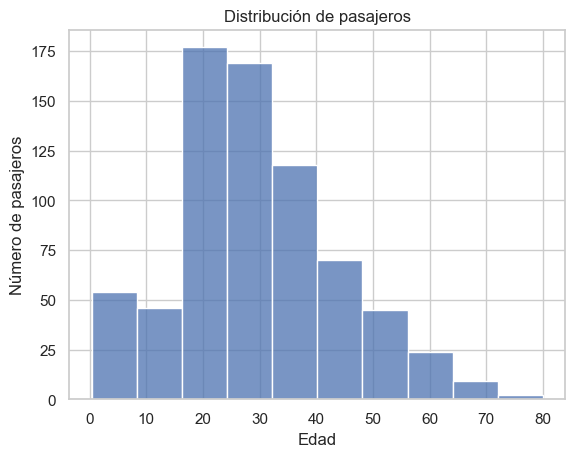

In [22]:
sns.histplot(
    data = df,
    x = "age",
    bins = 10
)

plt.title("Distribución de pasajeros")
plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.show()




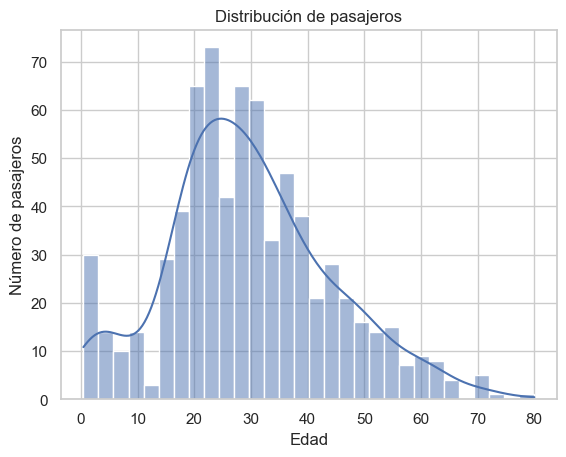

In [25]:
sns.histplot(
    data = df,
    x = "age",
    bins = 30,
    kde= True
)

plt.title("Distribución de pasajeros")
plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.show()

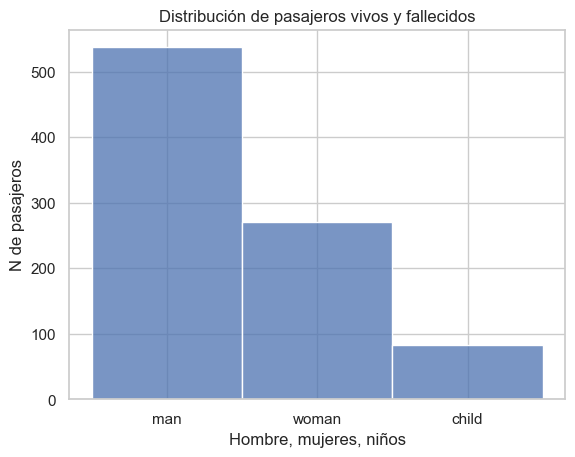

In [35]:
sns.histplot(
    data = df,
    x = "who",
    bins = 30
)

plt.title("Distribución de pasajeros vivos y fallecidos")
plt.xlabel("Hombre, mujeres, niños")
plt.ylabel("N de pasajeros")
plt.show()

In [32]:
vivos =  df[df["survived"] == 1]
fallecidos = df[df["survived"] == 0
                ]

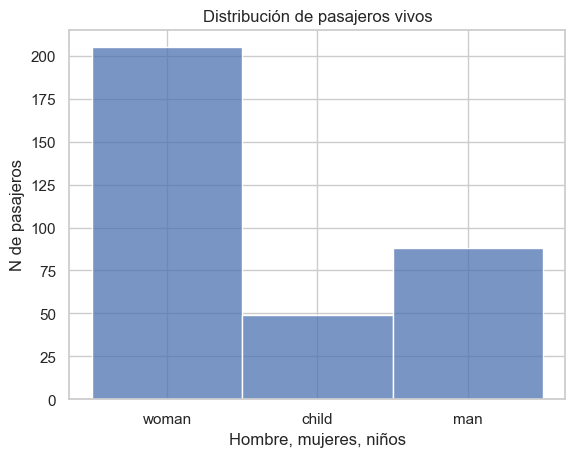

In [33]:
sns.histplot(
    data = vivos,
    x = "who",
    bins = 30
)

plt.title("Distribución de pasajeros vivos")
plt.xlabel("Hombre, mujeres, niños")
plt.ylabel("N de pasajeros")
plt.show()

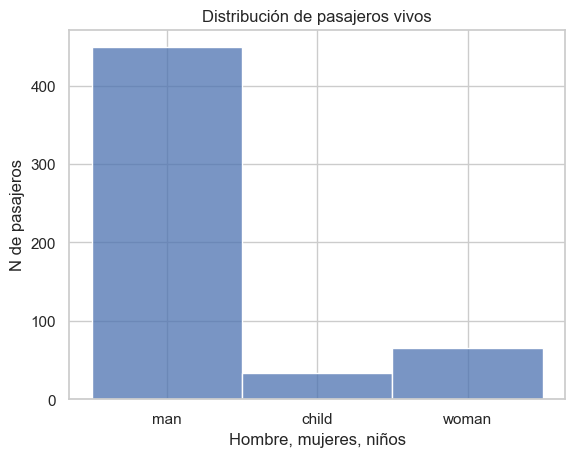

In [ ]:
sns.histplot(
    data = fallecidos,
    x = "who",
    bins = 30,
)

plt.title("Distribución de pasajeros fallecidos")
plt.xlabel("Hombre, mujeres, niños")
plt.ylabel("N de pasajeros")
plt.show()

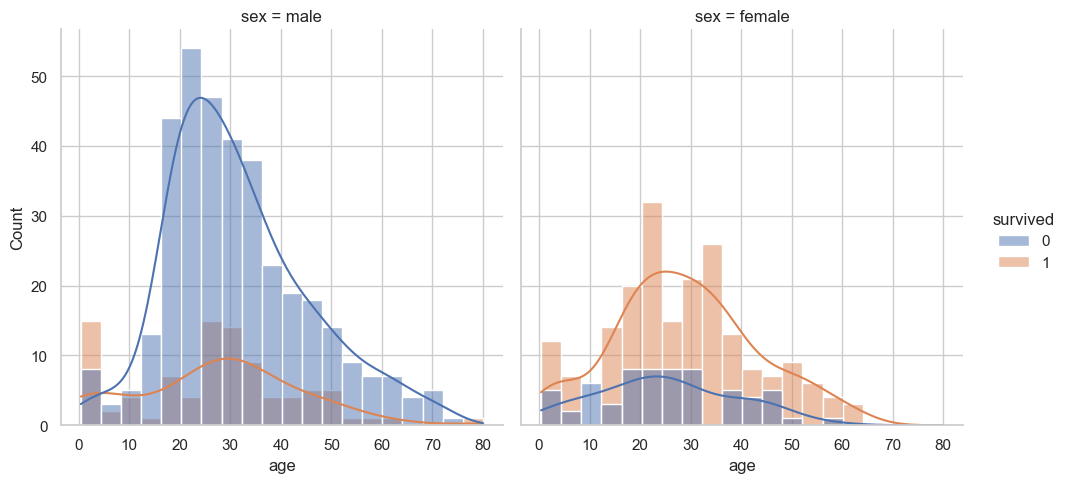

In [36]:
sns.displot(
    data=df,
    x="age",
    col="sex",
    hue="survived",
    kde=True
)

plt.show()

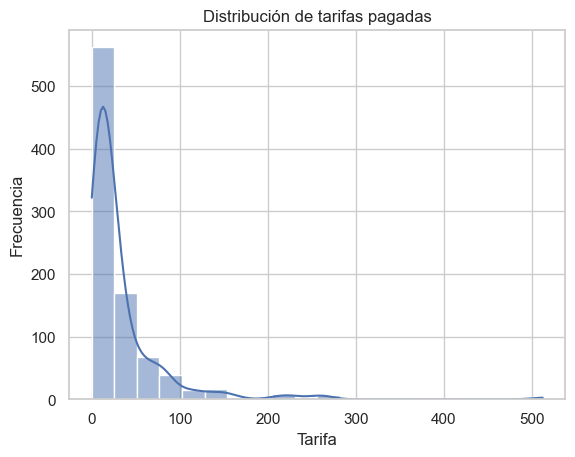

In [38]:
sns.histplot(
    data=df,
    x="fare",
    bins=20,
    kde=True
)

plt.title("Distribución de tarifas pagadas")
plt.xlabel("Tarifa")
plt.ylabel("Frecuencia")
plt.show()

In [39]:
# Saber si la persona  o personas que pagaron más sobrevivieron o no

In [ ]:
maxima_tarifa = df["fare"].max()
maxima_tarifa

512.3292

In [43]:
filtro = df["fare"] == maxima_tarifa

df[filtro]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True
679,1,1,male,36.0,0,1,512.3292,C,First,man,True,B,Cherbourg,yes,False
737,1,1,male,35.0,0,0,512.3292,C,First,man,True,B,Cherbourg,yes,True


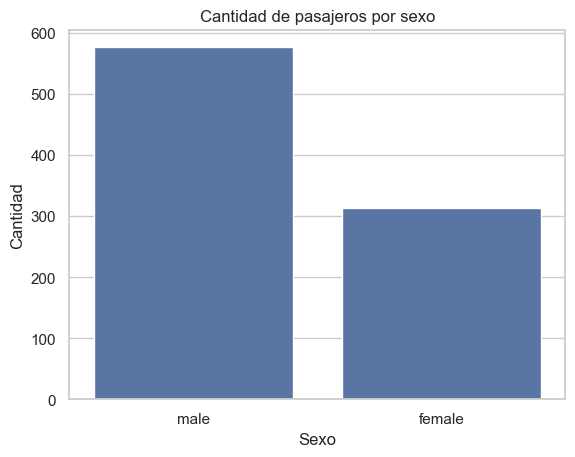

In [44]:
sns.countplot(
    data=df,
    x="sex"
)

plt.title("Cantidad de pasajeros por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")
plt.show()

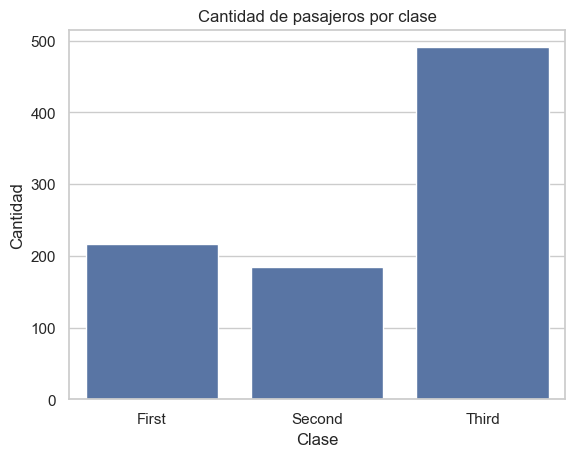

In [45]:
sns.countplot(
    data=df,
    x="class"
)

plt.title("Cantidad de pasajeros por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

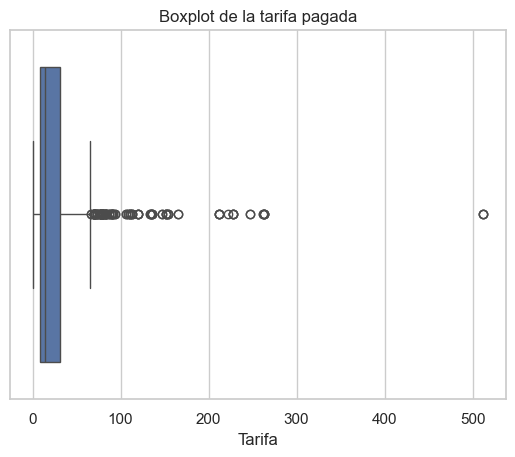

In [46]:
sns.boxplot(
    data=df,
    x="fare"
)

plt.title("Boxplot de la tarifa pagada")
plt.xlabel("Tarifa")
plt.show()

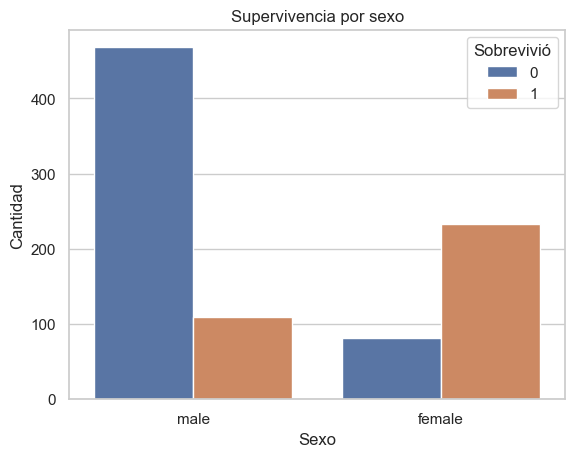

In [48]:
sns.countplot(
    data=df,
    x="sex",
    hue="survived"
)

plt.title("Supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")
plt.legend(title="Sobrevivió")
plt.show()

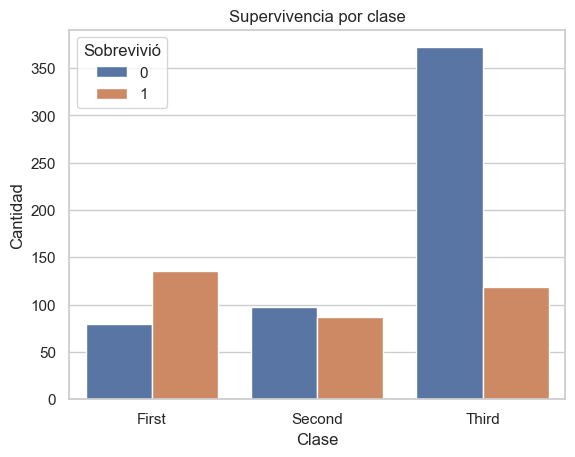

In [50]:
sns.countplot(
    data=df,
    x="class",
    hue="survived"
)

plt.title("Supervivencia por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.legend(title="Sobrevivió")
plt.show()

In [55]:
df_tercera_clase =  df[df["pclass"]==3]
df_tercera_clase

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False


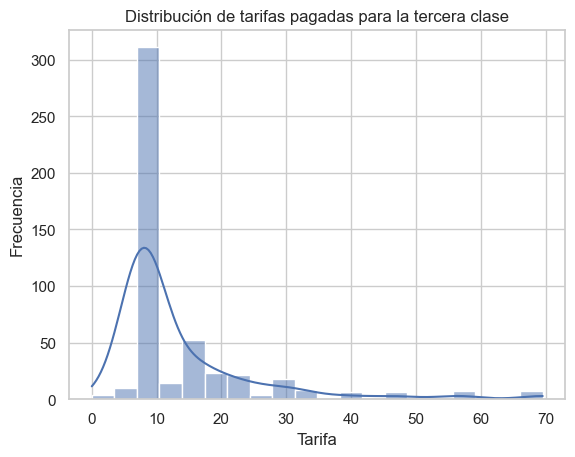

In [ ]:
## Graficar la distribución de la tarifa (fear) solo  de la tercera clase
sns.histplot(
    data=df_tercera_clase,
    x="fare",
    bins=20,
    kde=True
)

plt.title("Distribución de tarifas pagadas para la tercera clase")
plt.xlabel("Tarifa")
plt.ylabel("Frecuencia")
plt.show()

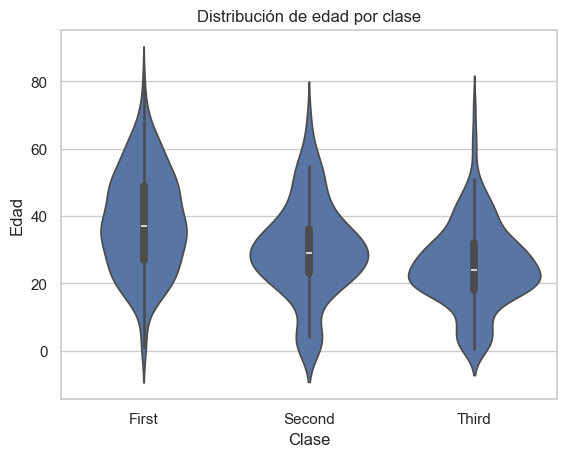

In [57]:
sns.violinplot(
    data=df,
    x="class",
    y="age"
)

plt.title("Distribución de edad por clase")
plt.xlabel("Clase")
plt.ylabel("Edad")
plt.show()

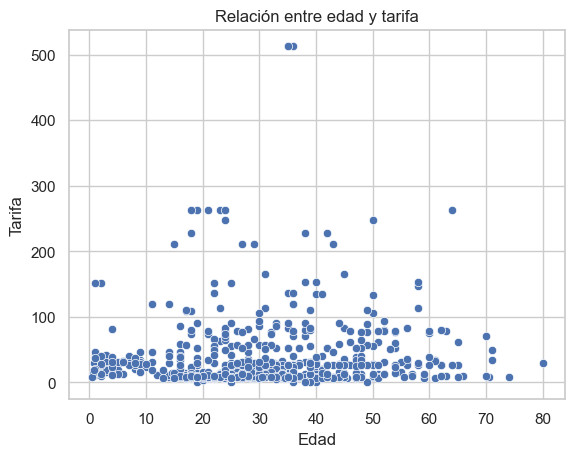

In [58]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare"
)

plt.title("Relación entre edad y tarifa")
plt.xlabel("Edad")
plt.ylabel("Tarifa")
plt.show()

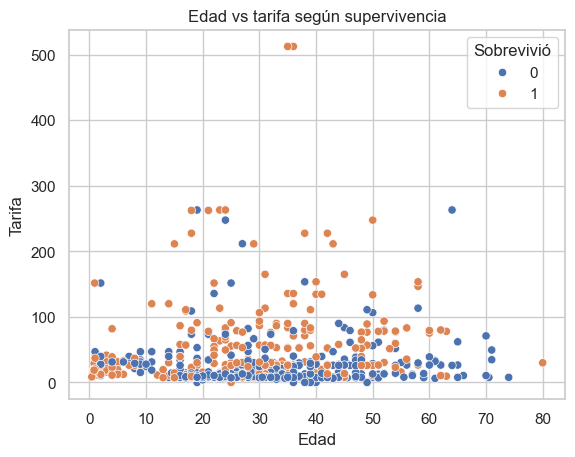

In [60]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Edad vs tarifa según supervivencia")
plt.xlabel("Edad")
plt.ylabel("Tarifa")
plt.legend(title="Sobrevivió") ##Coloca un titulo en el cuadro de anotaciones
plt.show()

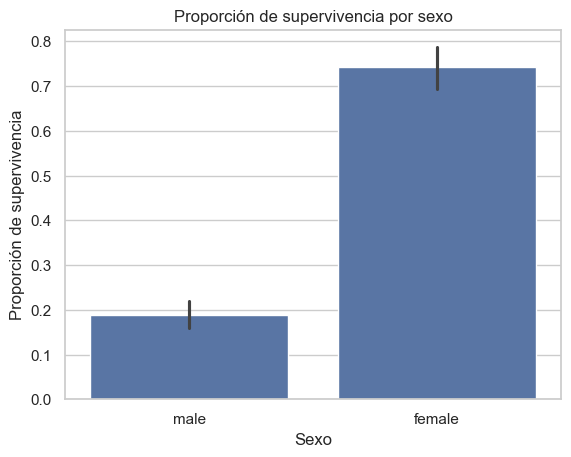

In [61]:
sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Proporción de supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Proporción de supervivencia")
plt.show()

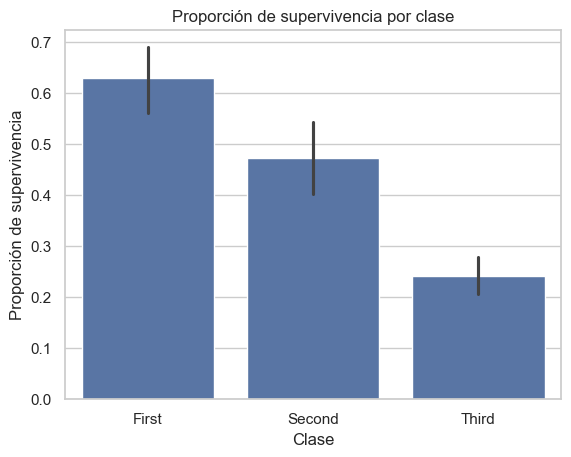

In [62]:
sns.barplot(
    data=df,
    x="class",
    y="survived"
)

plt.title("Proporción de supervivencia por clase")
plt.xlabel("Clase")
plt.ylabel("Proporción de supervivencia")
plt.show()

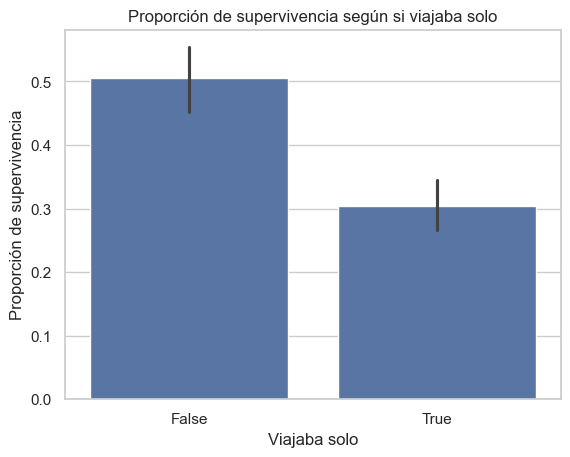

In [63]:
sns.barplot(
    data=df,
    x="alone",
    y="survived"
)

plt.title("Proporción de supervivencia según si viajaba solo")
plt.xlabel("Viajaba solo")
plt.ylabel("Proporción de supervivencia")
plt.show()

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [66]:
## Primero seleccionamos las variables numéricas
numeric_df = df.select_dtypes(include="number")
numeric_df.head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [68]:
matriz_correlacion= numeric_df.corr()
matriz_correlacion

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


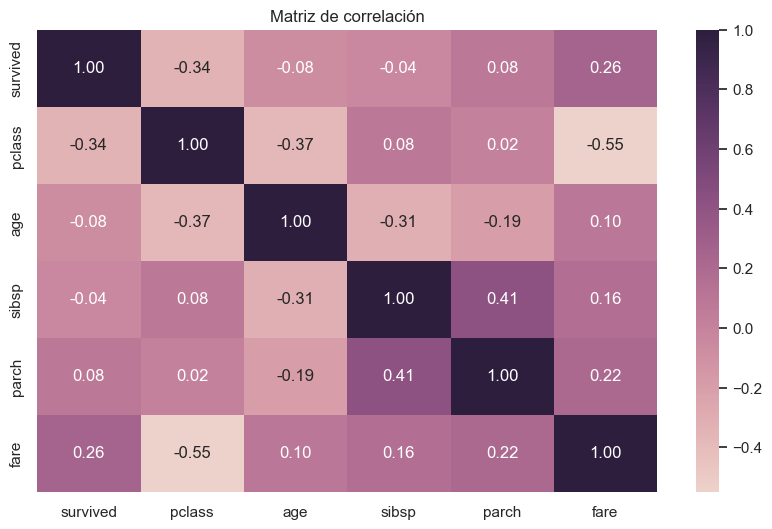

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap=sns.cubehelix_palette(as_cmap=True),  #Blues, crest
    fmt=".2f"

)
plt.title("Matriz de correlación")
plt.show()

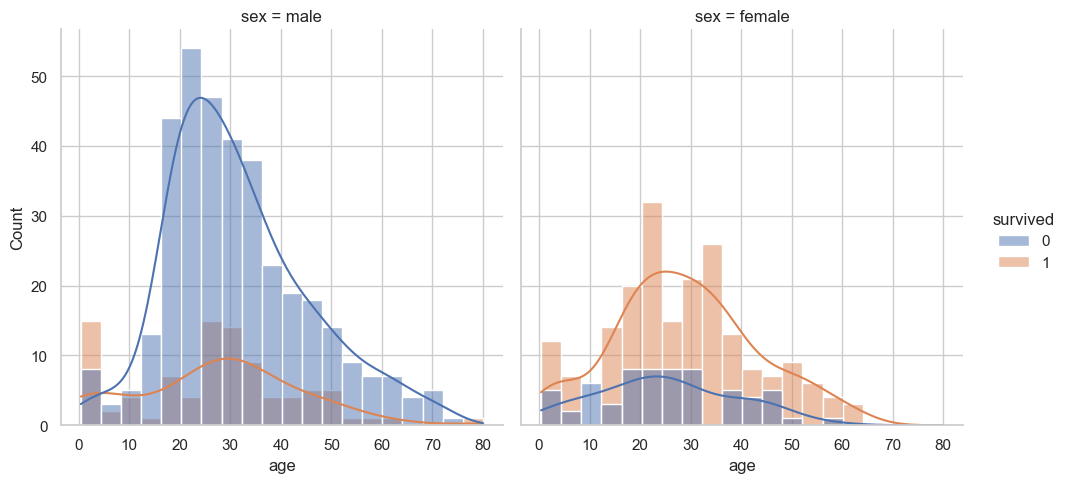

In [80]:
# Mostrar una gráfica separada pr facetas usando displot
sns.displot(
    data=df,
    x="age",
    col="sex",
    hue="survived",
    kde=True
)

plt.show()

C:\Users\Jessan\AppData\Local\Temp\ipykernel_1860\195429116.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Sobrevivió") ##Coloca un titulo en el cuadro de anotaciones


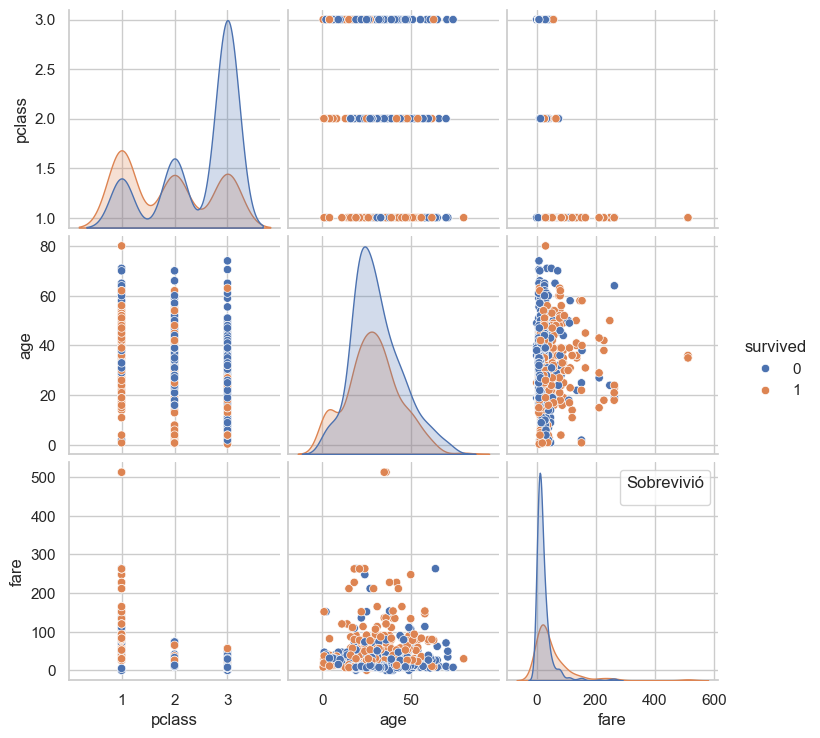

In [82]:
selected_columns = ["survived", "pclass", "age", "fare"]

sns.pairplot(
    data=df[selected_columns].dropna(),
    hue="survived"
)

plt.legend(title="Sobrevivió") ##Coloca un titulo en el cuadro de anotaciones

plt.show()

## Referencias

https://media.datacamp.com/legacy/image/upload/v1676302629/Marketing/Blog/Seaborn_Cheat_Sheet.pdf